In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import itertools 
import puck.experiments.permutation_guessing as pg
import puck.code_modules.colour_conversion.colour_conversion as conv


In [2]:
results_csv = pd.read_csv("../output/program_recognition_results_customdist.csv")
results_csv = results_csv.drop("Unnamed: 0", axis=1)
results_csv

,key,path,found_perm,true_perm,correct,overlap,luv_coords
0,a,../puck/data/images_copy/custom/michaels/high/...,afd,afd,True,3,"[array([ 77, 162, 157], dtype=uint8), array([ ..."
1,a,../puck/data/images_copy/custom/michaels/high/...,afd,afd,True,3,"[array([ 93, 166, 159], dtype=uint8), array([1..."
2,a,../puck/data/images_copy/custom/michaels/high/...,abd,afd,False,2,"[array([108, 173, 160], dtype=uint8), array([1..."
3,a,../puck/data/images_copy/custom/michaels/high/...,efd,afd,False,2,"[array([164, 131, 153], dtype=uint8), array([1..."
4,a,../puck/data/images_copy/custom/michaels/high/...,afd,afd,True,3,"[array([ 75, 164, 156], dtype=uint8), array([ ..."
...,...,...,...,...,...,...,...
235,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,"[array([ 82, 152, 135], dtype=uint8), array([ ..."
236,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,"[array([103, 141, 127], dtype=uint8), array([ ..."
237,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,"[array([100, 136, 126], dtype=uint8), array([ ..."
238,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,"[array([ 81, 139, 126], dtype=uint8), array([ ..."


Text(0.5, 1.0, 'Count of Overlaps per Permutation Key - Custom Paletee')

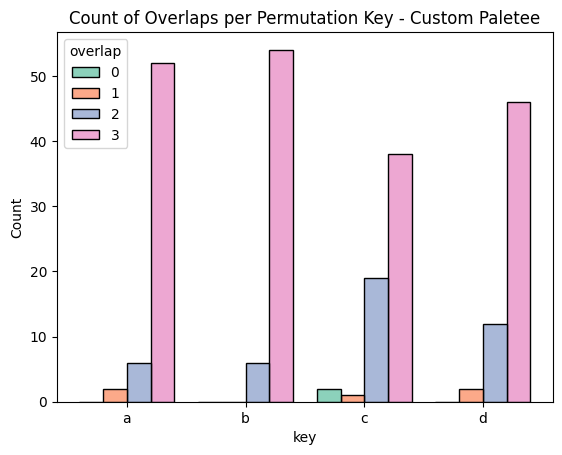

In [69]:
sns.histplot(data= results_csv, x = "key",hue="overlap",multiple="dodge", shrink=.8,palette= sns.color_palette("Set2")[:4])
plt.title("Count of Overlaps per Permutation Key - Custom Paletee")

In [3]:
results_csv_c = results_csv[results_csv["key"] == "c"]
print(results_csv_c["true_perm"].values[0])
results_csv_c["found_perm"].value_counts()

efg


found_perm
efg    38
ebg    18
gce     2
efe     1
ece     1
Name: count, dtype: int64

In [ ]:
results_csv_c_b =  results_csv[results_csv["found_perm"] == "ebg"]
bs = results_csv_c_b["luv_coords"].str.split("dtype=uint8",expand=True)[1]
bs = bs.str.slice(len("), array("))
bs = bs.str[:-2]
bs

128    [129, 124, 124]
130    [ 92, 130, 122]
131    [107, 132, 123]
132    [ 98, 130, 119]
133    [143, 123, 124]
134    [143, 123, 124]
137    [113, 138, 119]
139    [ 99, 132, 118]
140    [104, 135, 121]
147    [140, 121, 114]
149    [124, 124, 118]
153    [129, 137, 126]
166    [ 99, 129, 124]
174    [106, 128, 123]
175    [ 87, 126, 124]
176    [ 87, 126, 124]
177    [ 95, 123, 122]
179    [ 93, 130, 123]
Name: 1, dtype: object

In [34]:
points = [[129, 124, 124],
 [ 92, 130, 122],
[107, 132, 123],
 [ 98, 130, 119],
[143, 123, 124],
 [143, 123, 124],
[113, 138, 119],
[ 99, 132, 118],
[104, 135, 121],
[140, 121, 114],
[124, 124, 118],
 [129, 137, 126],
 [ 99, 129, 124],
 [106, 128, 123],
 [ 87, 126, 124],
[ 87, 126, 124],
[ 95, 123, 122]]

In [28]:
b_rgb= [255, 0, 255]
b_luv =conv.rgb_to_luv(b_rgb)
f_rgb = [219, 79, 137]
f_luv =conv.rgb_to_luv(f_rgb)
print(b_luv, f_luv)

[153 157  31] [139 161 122]


In [ ]:
def distance(detected,col)
    a =(int(detected[0])-int(col[0]))**2
    b= (int(detected[1])-int(col[1]))**2
    c =(int(detected[2])-int(col[2]))**2
    pos = a+b+c
    return math.sqrt(pos)

In [ ]:
b_diffs = []

In [9]:
results_csv_d = results_csv[results_csv["key"] == "d"]
print(results_csv_d["true_perm"].values[0])
results_csv_d["found_perm"].value_counts()

fff


found_perm
fff    46
fbf     4
bff     3
bbf     2
ffa     2
ffb     1
faf     1
aff     1
Name: count, dtype: int64

"#FE00FF",b
"#DB4F89",f

It frequently seems to get b and f confused.

In [10]:
results_csv_d = results_csv[results_csv["key"] == "d"]
print(results_csv_d["true_perm"].values[0])
results_csv_d["found_perm"].value_counts()

fff


found_perm
fff    46
fbf     4
bff     3
bbf     2
ffa     2
ffb     1
faf     1
aff     1
Name: count, dtype: int64

In [11]:
acc_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_csv[results_csv["key"] == k]
    accuracy = round((sum(key_selection["correct"])/len(key_selection["correct"])),3)
    acc_dict.update({k: accuracy})

acc_dict

{'a': 0.867, 'b': 0.9, 'c': 0.633, 'd': 0.767}

In [12]:
close_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_csv[results_csv["key"] == k]
    close = key_selection[(key_selection["overlap"]).astype(int) >= 2]
    close_acc = round((len(close)/len(key_selection["overlap"])),3)
    close_dict.update({k: close_acc})

close_dict

{'a': 0.967, 'b': 1.0, 'c': 0.95, 'd': 0.967}

In [40]:
def path_cutter(df):
    df["path2"] = df["path"].str.slice(len("../puck/data/images_copy/custom/"),len(df["path"]))
    print(df["path2"])
    df[['loc','height', 'perm', 'path']] = df.path2.str.split("/",expand=True)
    df = df.drop(["path2"], axis=1)

In [41]:
results_csv

,key,path,found_perm,true_perm,correct,overlap,path2
0,a,../puck/data/images_copy/custom/michaels/high/...,afd,afd,True,3,/michaels/high/A/custom_michaels_high_A_3.jpg
1,a,../puck/data/images_copy/custom/michaels/high/...,afd,afd,True,3,/michaels/high/A/custom_michaels_high_A_2.jpg
2,a,../puck/data/images_copy/custom/michaels/high/...,abd,afd,False,2,/michaels/high/A/custom_michaels_high_A_0.jpg
3,a,../puck/data/images_copy/custom/michaels/high/...,efd,afd,False,2,/michaels/high/A/custom_michaels_high_A_1.jpg
4,a,../puck/data/images_copy/custom/michaels/high/...,afd,afd,True,3,/michaels/high/A/custom_michaels_high_A_4.jpg
...,...,...,...,...,...,...,...
235,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,/jack_cole/medium/D/custom_jack_cole_medium_D_...
236,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,/jack_cole/medium/D/custom_jack_cole_medium_D_...
237,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,/jack_cole/medium/D/custom_jack_cole_medium_D_...
238,d,../puck/data/images_copy/custom/jack_cole/medi...,fff,fff,True,3,/jack_cole/medium/D/custom_jack_cole_medium_D_...


In [42]:
path_cutter(results_csv)
results_csv = results_csv.drop(["path2"], axis=1)

0           michaels/high/A/custom_michaels_high_A_3.jpg
1           michaels/high/A/custom_michaels_high_A_2.jpg
2           michaels/high/A/custom_michaels_high_A_0.jpg
3           michaels/high/A/custom_michaels_high_A_1.jpg
4           michaels/high/A/custom_michaels_high_A_4.jpg
                             ...                        
235    jack_cole/medium/D/custom_jack_cole_medium_D_4...
236    jack_cole/medium/D/custom_jack_cole_medium_D_2...
237    jack_cole/medium/D/custom_jack_cole_medium_D_3...
238    jack_cole/medium/D/custom_jack_cole_medium_D_1...
239    jack_cole/medium/D/custom_jack_cole_medium_D_0...
Name: path2, Length: 240, dtype: object


In [43]:
results_csv_c = results_csv[results_csv["key"] == "c"]
results_csv_c

,key,path,found_perm,true_perm,correct,overlap,loc,height,perm
120,c,custom_michaels_high_C_1.jpg,efg,efg,True,3,michaels,high,C
121,c,custom_michaels_high_C_0.jpg,efg,efg,True,3,michaels,high,C
122,c,custom_michaels_high_C_2.jpg,efg,efg,True,3,michaels,high,C
123,c,custom_michaels_high_C_3.jpg,efg,efg,True,3,michaels,high,C
124,c,custom_michaels_high_C_4.jpg,efg,efg,True,3,michaels,high,C
125,c,custom_michaels_short_C_1.jpg,efg,efg,True,3,michaels,short,C
126,c,custom_michaels_short_C_0.jpg,efg,efg,True,3,michaels,short,C
127,c,custom_michaels_short_C_2.jpg,efg,efg,True,3,michaels,short,C
128,c,custom_michaels_short_C_3.jpg,ebg,efg,False,2,michaels,short,C
129,c,custom_michaels_short_C_4.jpg,efe,efg,False,2,michaels,short,C


In [44]:
def pivot_creator(df:pd.DataFrame):
    entries = []
    for height, loc, in itertools.product(df["height"].unique(), df["loc"].unique()):
        selection = df[(df["height"] == height) & (df["loc"] == loc)]
        overlap_avg = stats.mean(selection["overlap"])
        entries.append({"height": height, "loc": loc, "overlap_avg": overlap_avg})
    return pd.DataFrame(entries, columns=["height", "loc", "overlap_avg"])

<Axes: xlabel='height', ylabel='loc'>

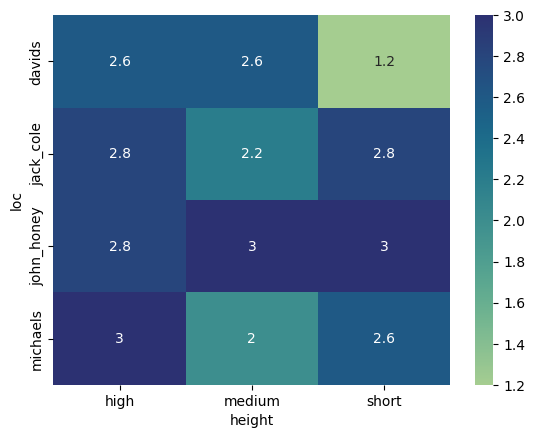

In [45]:
pivot_df = pivot_creator(results_csv_c)
results_c_pivot = (pivot_df.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_c_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))

In [47]:
results_csv_c_low= results_csv_c[results_csv_c["height"] == "short"]
results_csv_c_low["found_perm"].value_counts()

found_perm
efg    13
ebg     3
gce     2
efe     1
ece     1
Name: count, dtype: int64

In [60]:
results_csv_c["found_perm"].value_counts()

found_perm
efg    38
ebg    18
gce     2
efe     1
ece     1
Name: count, dtype: int64

In [61]:
results_dark_csv = pd.read_csv("../output/program_recognition_results_dark.csv")
results_dark_csv = results_dark_csv.drop("Unnamed: 0", axis=1)
results_dark_csv

,key,path,found_perm,true_perm,correct,overlap
0,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
1,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
2,a,../puck/data/images_copy/dark/michaels/high/A/...,ahd,afd,False,2
3,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
4,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
...,...,...,...,...,...,...
235,d,../puck/data/images_copy/dark/jack_cole/medium...,ffh,fff,False,2
236,d,../puck/data/images_copy/dark/jack_cole/medium...,fff,fff,True,3
237,d,../puck/data/images_copy/dark/jack_cole/medium...,dff,fff,False,2
238,d,../puck/data/images_copy/dark/jack_cole/medium...,fff,fff,True,3


Text(0.5, 1.0, 'Count of Overlaps per Permutation Key - Dark Palette')

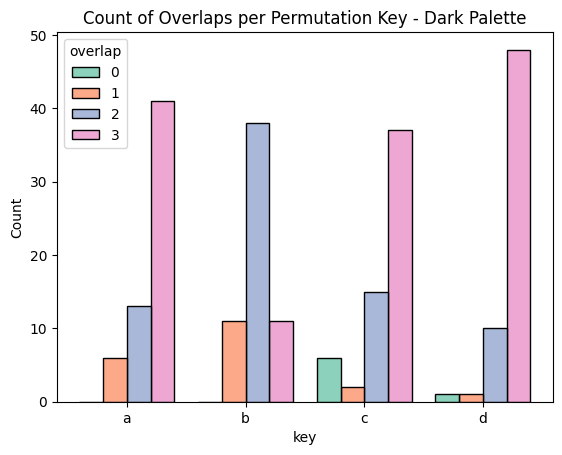

In [68]:
sns.histplot(data= results_dark_csv, x = "key",hue="overlap",multiple="dodge", shrink=.8,palette= sns.color_palette("Set2")[:4])
plt.title("Count of Overlaps per Permutation Key - Dark Palette")

In [51]:
path_cutter(results_dark_csv)
results_dark_csv = results_dark_csv.drop(["path2"], axis=1)

0            chaels/high/A/dark_michaels_high_A_1.jpg
1            chaels/high/A/dark_michaels_high_A_0.jpg
2            chaels/high/A/dark_michaels_high_A_2.jpg
3            chaels/high/A/dark_michaels_high_A_3.jpg
4            chaels/high/A/dark_michaels_high_A_4.jpg
                            ...                      
235    ck_cole/medium/D/dark_jack_cole_medium_D_1.jpg
236    ck_cole/medium/D/dark_jack_cole_medium_D_0.jpg
237    ck_cole/medium/D/dark_jack_cole_medium_D_2.jpg
238    ck_cole/medium/D/dark_jack_cole_medium_D_3.jpg
239    ck_cole/medium/D/dark_jack_cole_medium_D_4.jpg
Name: path2, Length: 240, dtype: object


In [63]:
results_dark_csv

,key,path,found_perm,true_perm,correct,overlap
0,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
1,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
2,a,../puck/data/images_copy/dark/michaels/high/A/...,ahd,afd,False,2
3,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
4,a,../puck/data/images_copy/dark/michaels/high/A/...,afd,afd,True,3
...,...,...,...,...,...,...
235,d,../puck/data/images_copy/dark/jack_cole/medium...,ffh,fff,False,2
236,d,../puck/data/images_copy/dark/jack_cole/medium...,fff,fff,True,3
237,d,../puck/data/images_copy/dark/jack_cole/medium...,dff,fff,False,2
238,d,../puck/data/images_copy/dark/jack_cole/medium...,fff,fff,True,3


In [53]:
results_dark_csv_c = results_dark_csv[results_dark_csv["key"] == "c"]
results_dark_csv_b = results_dark_csv[results_dark_csv["key"] == "b"]
results_dark_csv_d = results_dark_csv[results_dark_csv["key"] == "d"]

In [70]:
print(results_dark_csv_c["true_perm"].values[0])
results_dark_csv_c["found_perm"].value_counts()

efg


found_perm
efg    37
ehg    11
bfg     3
gef     3
geh     2
bfe     2
ged     1
edg     1
Name: count, dtype: int64

In [55]:
print(results_dark_csv_b["true_perm"].values[0])
results_dark_csv_b["found_perm"].value_counts()

ahc


found_perm
adc    38
ahc    11
adg     9
abg     2
Name: count, dtype: int64

In [56]:
print(results_dark_csv_d["true_perm"].values[0])
results_dark_csv_d["found_perm"].value_counts()

fff


found_perm
fff    48
ffh     6
fhf     2
hhh     1
fhh     1
fdf     1
dff     1
Name: count, dtype: int64

In [65]:
acc_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_dark_csv[results_dark_csv["key"] == k]
    accuracy = round((sum(key_selection["correct"])/len(key_selection["correct"])),3)
    acc_dict.update({k: accuracy})

acc_dict

{'a': 0.683, 'b': 0.183, 'c': 0.617, 'd': 0.8}

In [66]:
close_dict = {}
for k in ['a','b','c', 'd']:
    key_selection =results_dark_csv[results_dark_csv["key"] == k]
    close = key_selection[(key_selection["overlap"]).astype(int) >= 2]
    close_acc = round((len(close)/len(key_selection["overlap"])),3)
    close_dict.update({k: close_acc})

close_dict

{'a': 0.9, 'b': 0.817, 'c': 0.867, 'd': 0.967}

<Axes: xlabel='height', ylabel='loc'>

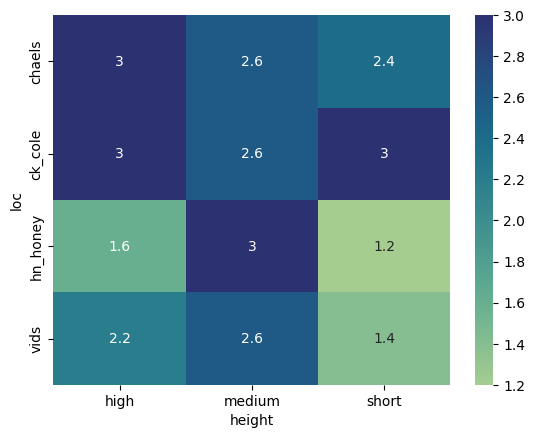

In [59]:
pivot_df_dark = pivot_creator(results_dark_csv_c)
results_dark_c_pivot = (pivot_df_dark.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_dark_c_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))

<Axes: xlabel='height', ylabel='loc'>

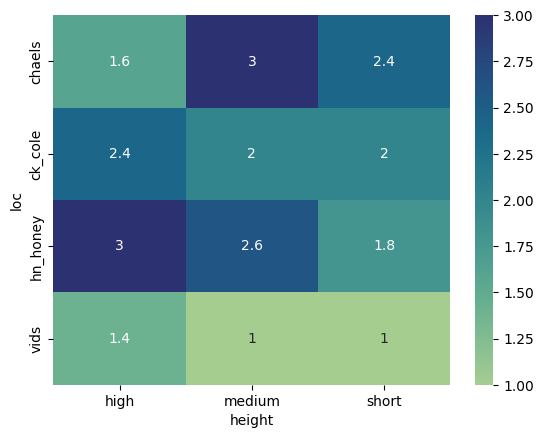

In [44]:
pivot_df_dark_b = pivot_creator(results_dark_csv_b)
results_dark_b_pivot = (pivot_df_dark_b.pivot(index="loc", columns="height", values="overlap_avg"))
sns.heatmap(results_dark_b_pivot, annot=True, cmap=sns.color_palette("crest", as_cmap=True))